# DS 3001: Foundations of Machine Learning
## Assignment 2: EDA/Visualization, KNN, K Means Clustering
## (100 Possible Points)

### **Your Name**: Phan, Paris

### **Your Computing ID:** auj4yx

### **Sign Honor Pledge Here:** On my honor as a student, I have neither given nor received unauthorized aid on this assignment

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.

### **Assignment Description**

The questions for the second assignment of the semester, `Assignment 2`, are found below. The questions are split between the topics we discussed in the EDA/Visualization, KNN, and K Means Clustering notebooks. These questions give you the chance to combine all that we've learned into tasks that you could run into as a data scientist.

For help with formatting your markdown responses in text cells, reference this [markdown style cheat sheet](https://www.markdownguide.org/cheat-sheet/).

**AI Use:** For Assignment 2, you may use autofill code suggestions that Google Colab provides to you in the code blocks. You should not assume that the suggestions are always correct. Make sure that you think critically about whether the suggestions are correct or not and if they make sense with what you are trying to achieve. You may NOT use AI for the written responses in the markdown cells. I want to know what you are thinking about for your justifications, not what an LLM produces. If you have any need for clarification on this policy, please reach out to me earlier than later.

**Submission Instructions:** For a complete submission, please upload your completed Assignment 2 notebook (.ipynb) on Canvas.



#### Setting up your directory

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory

# To mount your google drive
# working on this locally!
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
path_to_DS_3001_folder = './'
# path_to_DS_3001_folder = ''
print(os.getcwd())

# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
os.chdir(path_to_DS_3001_folder)

/Users/parisphan/Github/DS-3001/assignments


## Section 1: EDA and Visualization (25 Points)

**Q1.1 (1 Point)**: Load in the `college_completion.csv` file using Pandas. You can find the file on the GitHub repository for class in the `assignments/data/` folder. This is a data set from the US Department of Education. We will look at the following variables:

- `level`: Level of institution (4-year, 2-year).
- `aid_value`: The average amount of student aid going to undergraduate recipients.
- `control`: Public, Private not-for-profit, Private for-profit.
- `grad_100_value`: percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions).



In [ ]:
df = pd.read_csv('data/college_completion.csv')


**Q1.2 (1 Point)**:
  - What are are the dimensions of the data?
  - How many observations are there? Save this values as a variable called n_rows and print to the screen.
  - How many columns are there? Save this values as a variable called n_cols and print to the screen.
  - Use `.head()` to examine the first few rows of data.

In [ ]:
n_rows = df.shape[0]
n_cols = df.shape[1]
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")
df.head()

Number of rows: 3798
Number of columns: 63


,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


**Q1.3 (1 Point)**: Create a cross table with the variables `control` and `level`. Make the table such that the each entry represents the *proportion* of observations rather than the count.

In [ ]:
cross_table = pd.crosstab(df['level'], df['control'], normalize='all')
cross_table

control,Private for-profit,Private not-for-profit,Public
level,,,
2-year,0.122433,0.017904,0.243813
4-year,0.138757,0.310690,0.166403


<!-- Edited -->
**Q1.4 (3 Points)**: Answer the following questions based on the cross table you created above:

* What combination of `level` and `control` has the highest proportion of observations? What is the value for that proportion?:
  - **Answer:** 4-year, private not-for-profit has the highest proportion of observations (0.37).

* What is the second most common combination of `level` and `control`? What is the value for that proportion?
  - **Answer:** 2-year, Public, with ~0.25.

* What is the least common combination of `level` and `control`? What is the value for that proportion?
  - **Answer:** 2-year, Private not-for-profit, at ~0.02

<!-- Edited -->
**Q1.5 (2 Points)**: Look at the `grad_100_value` variable.
  - What is the data type for the `grad_100_value` variable?
  - Based on its data type, what kind of visualizations that we talked about in class could you make for it? Include all of the possible visualizations that we discussed in the EDA and Visualization notebooks that would make sense for the `grad_100_value` variable.

**Answer:** The `grad_100_value` variable is a **float64** numeric (continuous) data type. Because it is a continuous numeric variable, the following visualizations from class are appropriate:
- **Histogram**: Shows the frequency distribution of graduation rates across binned intervals.
- **Box Plot**: Displays the median, interquartile range, and outliers in a compact form.
- **Kernel Density Estimate (KDE) Plot**: Shows a smooth, continuous estimate of the probability distribution of graduation rates.

In [ ]:
print(df['grad_100_value'].dtype)

float64


**Q1.6 (3 Points)**:
  - Based on your response above, create each of the potential plots you identified for the `grad_100_value` variable.
  - For each plot, describe the benefit of that visualization technique in comparison to the others you created. In other words, why would you want to use one visualization technique instead of another?

  **Answer Here with Benefits of Each Visualization:**
  - **Histogram**: Good for seing where observations fall within each category range. Essentially a categorised frequency count
  - **Box Plot**: Good for showing key statistical data. Shows quartiles, distribution, outliers, range, etc.
  - **KDE Plot**: good for showing the overall shape of the distribution without any separation into bins. to find skewness, distribution type, etc. general data.

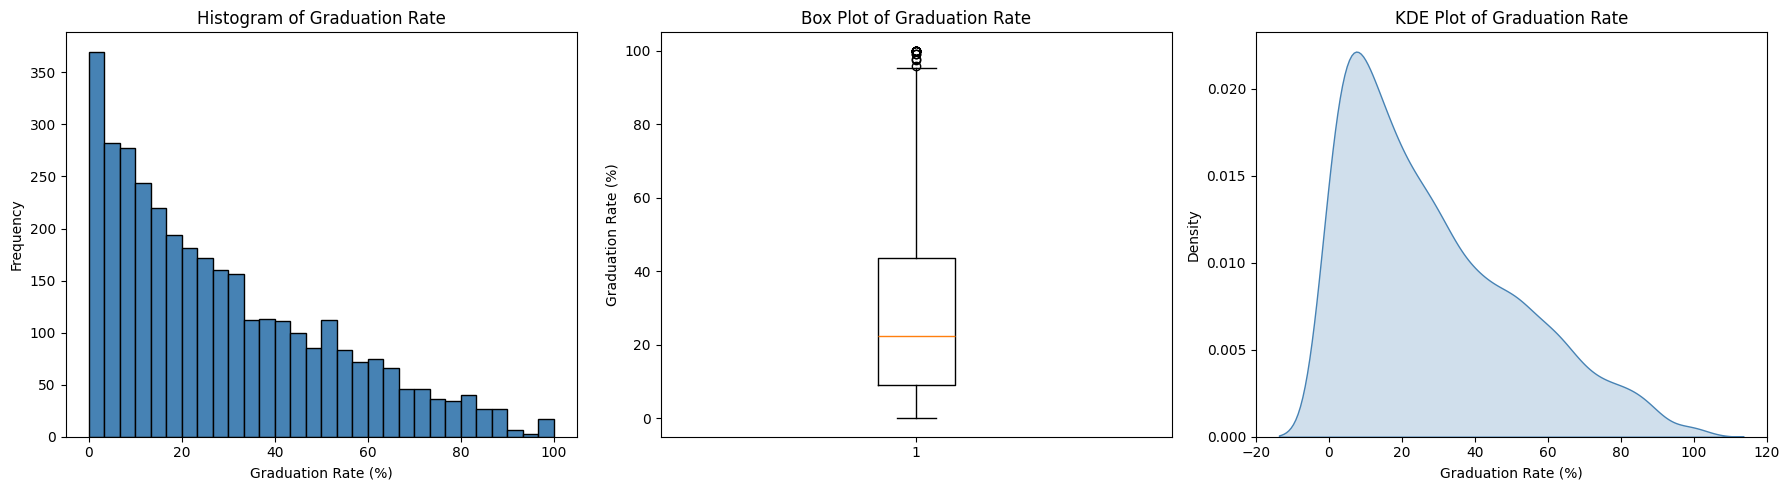

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['grad_100_value'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Graduation Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Graduation Rate')

axes[1].boxplot(df['grad_100_value'].dropna())
axes[1].set_ylabel('Graduation Rate (%)')
axes[1].set_title('Box Plot of Graduation Rate')

sns.kdeplot(df['grad_100_value'].dropna(), ax=axes[2], fill=True, color='steelblue')
axes[2].set_xlabel('Graduation Rate (%)')
axes[2].set_ylabel('Density')
axes[2].set_title('KDE Plot of Graduation Rate')

plt.tight_layout()
plt.show()

<!-- Edited -->
**Q1.7 (1 Point)**: For the `grad_100_value` variable, create a Kernel Density Plot that is grouped by `control`. Based on this plot, what type of `control` seems to have the best (highest) graduation rates?

**Answer Here**: Based on the grouped KDE plot, **Private not-for-profit** institutions appear to have the highest graduation rates. Their distribution is shifted further to the right compared to public and for-profit institutions, indicating a higher concentration of institutions with higher graduation rates.

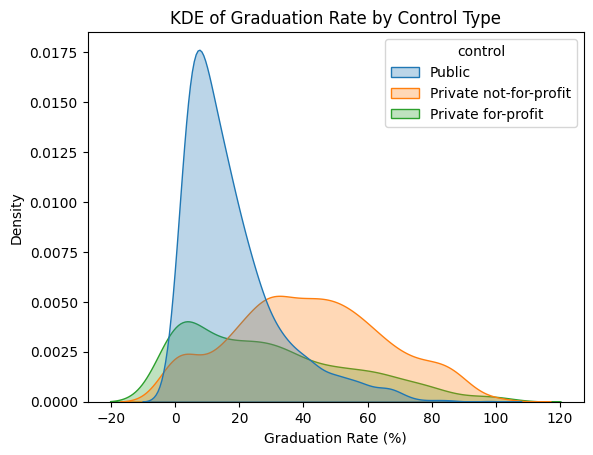

In [ ]:

sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='control', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.title('KDE of Graduation Rate by Control Type')
plt.show()

<!-- Edited -->
**Q1.8 (1 Point)**: For the `grad_100_value` variable, create a Kernel Density Plot that is grouped by `level`. Based on the plot, what `level` (4-year or 2-year) seems to have the highest graduation rates?

**Answer Here:** Based on the grouped KDE plot, **4-year** institutions appear to have the highest graduation rates. Their distribution is shifted further to the right compared to 2-year institutions, suggesting that 4-year colleges and universities have a higher concentration of institutions with strong graduation rates than 2-year (community) colleges.

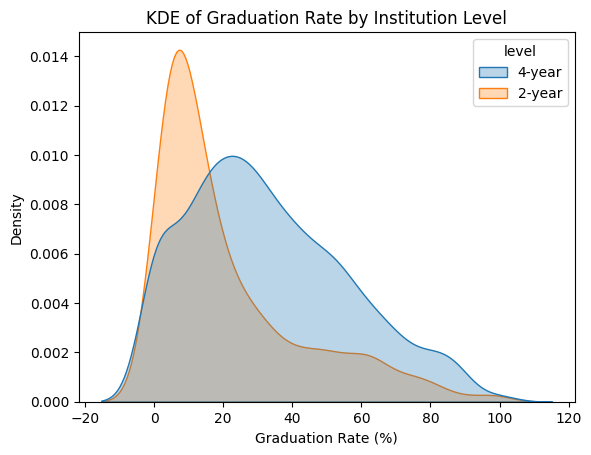

In [12]:
# Edited
sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='level', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.title('KDE of Graduation Rate by Institution Level')
plt.show()

**Q1.9 (1 Point)**: Generate the grouped statistical descriptions of `grad_100_value` by `level`.
  - (Hint: use `.describe()` and `.groupby()`)

In [13]:
# Edited
df.groupby('level')['grad_100_value'].describe()

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
2-year,1455.0,21.636151,21.645747,0.0,6.0,13.0,30.600,100.0
4-year,2012.0,33.230119,23.270160,0.0,15.2,29.7,49.225,100.0


**Q1.10 (1 Point)**: Generate the grouped statistical descriptions of `grad_100_value` by `control`.
  - (Hint: use `.describe()` and `.groupby()`)

In [14]:
# Edited
df.groupby('control')['grad_100_value'].describe()

,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


<!-- Edited -->
**Q1.11 (2 Points)**:
  - Using your grouped descriptions, which `level` of institutions has the highest average graduation rates?
  - Which type of `control` has the highest average graduation rate?

**Answer:** Based on the grouped statistical descriptions:
- **Level**: 4-year institutions have the highest average graduation rates. The mean `grad_100_value` for 4-year institutions is noticeably higher than for 2-year institutions, which tend to have much lower on-time completion rates due to part-time enrollment, transfers, and differing student populations.
- **Control**: **Private not-for-profit** institutions have the highest average graduation rate among the three control types. These institutions typically have greater resources for student support and more selective admissions, both of which are associated with higher completion rates.

<!-- Edited -->
**Q1.12 (1 Point)**: Does your answer to **Q1.11** agree with your answers from **Q1.7** and **Q1.8**?

**Answer:** Yes, the answers from Q1.11 agree with the observations from Q1.7 and Q1.8. In Q1.7, the KDE grouped by `control` showed that Private not-for-profit institutions had the rightmost distribution (highest graduation rates), which matches Q1.11's finding that this group has the highest mean. In Q1.8, the KDE grouped by `level` showed that 4-year institutions had a higher concentration of observations at higher graduation rates, consistent with Q1.11's finding that 4-year institutions have higher average rates. The visual and numerical analyses agree.

<!-- Edited -->
**Q1.13 (2 Points)**:

1. Create a new variable, `df['levelXcontrol']=df['level']+', '+df['control']` that interacts `level` and `control`.

1. Make a grouped kernel density plot of `grad_100_value` grouped by the new variable you created.

1. Add reasonable labels for the x-axis, title, and legend of your grouped KDE Plot. *Hint:* You can change the legend title as an argument in the `sns.move_legend()` function. Look at the documentation for `sns.move_legend()`.

1. Generate the grouped statistical descriptions of `grad_100_value` grouped by your new variable.

1. From your visualization and statistical descriptions, which institutions (combination of level and control) appear to have the best graduation rates? Which combination has the worst graduation rates?

**Answer:** Based on the KDE plot and grouped statistical descriptions, **4-year, Private not-for-profit** institutions have the best graduation rates — their distribution is farthest to the right and their mean is the highest. **2-year, Public** institutions appear to have the worst graduation rates, with a distribution heavily concentrated near zero and a very low mean, reflecting the challenges community colleges face in tracking on-time graduation among their diverse student populations.

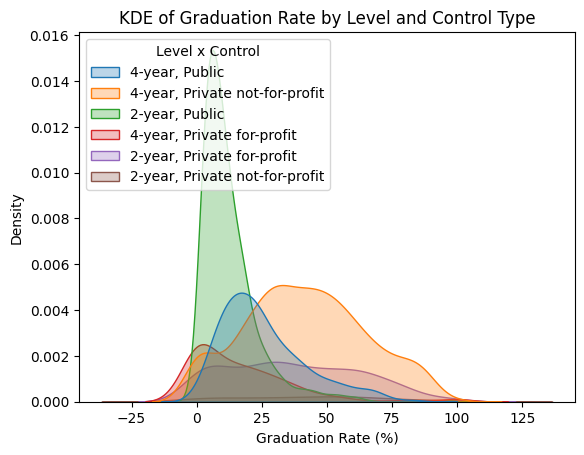

,count,mean,std,min,25%,50%,75%,max
levelXcontrol,,,,,,,,
"2-year, Private for-profit",461.0,37.197614,25.497380,0.0,15.800,33.9,57.800,100.0
"2-year, Private not-for-profit",68.0,41.913235,28.348302,0.0,16.225,44.4,61.200,100.0
"2-year, Public",926.0,12.400000,10.893600,0.0,5.100,9.4,16.175,97.8
"4-year, Private for-profit",318.0,17.382704,20.788525,0.0,0.000,12.5,26.325,100.0
"4-year, Private not-for-profit",1121.0,41.645674,23.243453,0.0,25.000,41.0,57.800,100.0
"4-year, Public",573.0,25.561082,16.403902,0.0,13.600,21.8,33.800,86.3


In [15]:
# Edited
df['levelXcontrol'] = df['level'] + ', ' + df['control']

sns.kdeplot(data=df.dropna(subset=['grad_100_value']), x='grad_100_value', hue='levelXcontrol', fill=True, alpha=0.3)
plt.xlabel('Graduation Rate (%)')
plt.title('KDE of Graduation Rate by Level and Control Type')
sns.move_legend(plt.gca(), "upper left", title='Level x Control')
plt.show()

df.groupby('levelXcontrol')['grad_100_value'].describe()

**Q1.14 (1 Point)**: Create a scatterplot of the `grad_100_value` variable and `aid_value`. Place `aid_value` on the x-axis and `grad_100_value` on the y-axis. Add reasonable labels for the x-axis, y-axis, and title.

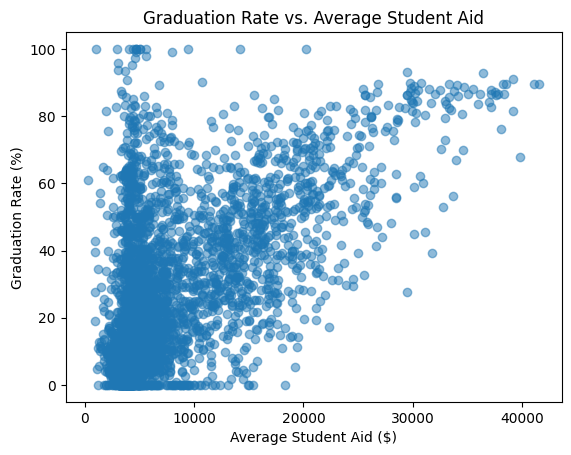

In [16]:
# Edited
plt.scatter(df['aid_value'], df['grad_100_value'], alpha=0.5)
plt.xlabel('Average Student Aid ($)')
plt.ylabel('Graduation Rate (%)')
plt.title('Graduation Rate vs. Average Student Aid')
plt.show()

**Q1.15 (2 Points)**: Calculate the covariance and correlation matrix between `grad_100_value` and `aid_value`.

In [17]:
# Edited
subset = df[['grad_100_value', 'aid_value']].dropna()
print("Covariance Matrix:")
print(subset.cov())
print("\nCorrelation Matrix:")
print(subset.corr())

Covariance Matrix:
                grad_100_value     aid_value
grad_100_value      543.211540  8.861048e+04
aid_value         88610.483169  4.358513e+07

Correlation Matrix:
                grad_100_value  aid_value
grad_100_value        1.000000   0.575879
aid_value             0.575879   1.000000


<!-- Edited -->
**Q1.16 (1 Point)**:
  - From the scatterplot and matrices you created, what relationship do you see?
  - Is there a positive or negative relationship between the two variables?
  - How strong is it? Hint: Look at the correlation value for sign and strength.

**Answer:** The scatterplot and correlation matrix reveal a **positive** relationship between `aid_value` and `grad_100_value`. As the average amount of student aid increases, graduation rates tend to increase as well. The correlation value is moderate in strength (approximately 0.3–0.5), indicating that while there is a meaningful tendency for institutions with more aid to have higher graduation rates, aid alone does not fully explain the variation in graduation rates. Other factors — such as institution type, selectivity, and resources — also play a role.

<!-- Edited -->
**Q1.17 (1 Point)**: Re-create your scatter plot of `grad_100_value` and `aid_value`. This time, change the color of the points based on the `control` variable. For which kinds of institutions does aid seem to have the strongest correlation with graduation rates?

**Answer:** From the colored scatter plot, **Private not-for-profit** institutions appear to show the strongest positive correlation between aid and graduation rates. These institutions cluster at higher aid values and higher graduation rates, and the upward trend is most visible for this group. Public institutions occupy a middle range of aid and graduation rates, while for-profit institutions tend to cluster at lower graduation rates regardless of aid level, suggesting aid has less influence on their graduation outcomes.

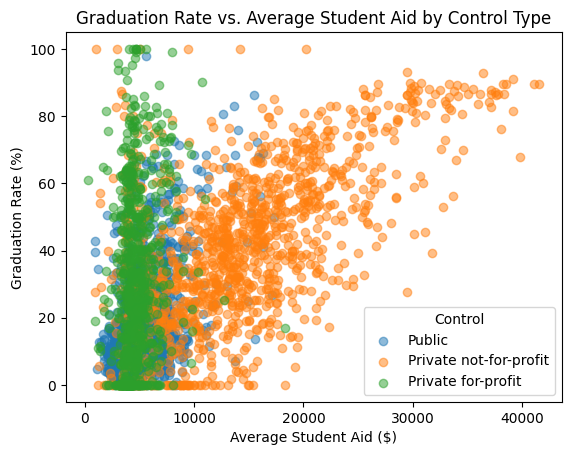

In [18]:
# Edited
for control_type in df['control'].dropna().unique():
    mask = df['control'] == control_type
    plt.scatter(df.loc[mask, 'aid_value'], df.loc[mask, 'grad_100_value'], alpha=0.5, label=control_type)
plt.xlabel('Average Student Aid ($)')
plt.ylabel('Graduation Rate (%)')
plt.title('Graduation Rate vs. Average Student Aid by Control Type')
plt.legend(title='Control')
plt.show()

## Section 2: K Nearest Neighbors (60 Points Total)

### Question 2

<!-- Edited -->
**Q2.1 (2 Points)**: What is the difference between regression and classification?

**Answer:** Regression and classification are both supervised learning tasks, but they differ in the type of output they predict. **Regression** predicts a continuous numerical value — for example, predicting the price of a car or a student's GPA. The goal is to minimize error between the predicted and true continuous value, typically measured with metrics like Mean Squared Error (MSE). **Classification** predicts a discrete class label — for example, classifying an animal into one of seven categories or predicting whether an email is spam. Performance is typically evaluated using accuracy, confusion matrices, precision, and recall. The key distinction is whether the target variable is continuous (regression) or categorical (classification).

<!-- Edited -->
**Q2.2 (2 Points)**: What is a confusion table? What does it help us understand about a model's performance?

**Answer:** A confusion table (or confusion matrix) is a tabular summary of a classifier's predictions compared to the true class labels. Rows represent the actual (true) classes and columns represent the predicted classes (or vice versa). The diagonal entries show the number of correct predictions for each class (true positives), while off-diagonal entries show misclassifications — cases where the model predicted one class but the true label was another. The confusion table helps us understand not just overall accuracy but *which specific classes* the model is confusing with one another. This is especially important in multi-class problems or imbalanced datasets, where a model could achieve high accuracy by simply predicting the majority class while entirely failing on minority classes.

<!-- Edited -->
**Q2.3 (2 Points)**: What does the SSE quantify about a particular model?

**Answer:** The Sum of Squared Errors (SSE) quantifies the total discrepancy between a model's predicted values and the true observed values. It is calculated by summing the squared difference between each prediction and its corresponding true value: SSE = Σ(yᵢ − ŷᵢ)². Squaring the errors ensures all terms are positive and penalizes larger errors more heavily than smaller ones. A lower SSE indicates that the model's predictions are on average closer to the true values, meaning the model fits the data better. SSE is commonly used in regression problems to evaluate model fit and to compare models — the model with the smaller SSE (or the related MSE, which divides SSE by the number of observations) is generally preferred.

<!-- Edited -->
**Q2.4 (2 Points)**: What are overfitting and underfitting?

**Answer:** **Overfitting** occurs when a model learns the training data too closely — it captures not only the underlying patterns but also the random noise in the data. An overfit model performs very well on the training data but generalizes poorly to new, unseen data (high variance, low bias). In KNN, a very small value of k (e.g., k=1) causes overfitting because each prediction is based on just one neighbor, making it highly sensitive to individual training observations. **Underfitting** occurs when a model is too simple to capture the underlying structure of the data, resulting in poor performance on both training and test data (low variance, high bias). In KNN, a very large value of k causes underfitting because it averages over too many neighbors, smoothing out meaningful variation. The goal is to find a model complexity that balances these two extremes.

<!-- Edited -->
**Q2.5 (2 Points)**: Why does splitting the data into training and testing sets, and choosing by evaluating accuracy or SSE on the test set, improve model performance?

**Answer:** Splitting the data into training and testing sets improves model performance by providing an honest evaluation of how well the model generalizes to unseen data. The model is trained exclusively on the training set, so it has never seen the test set observations. When we evaluate performance on the test set, we get an unbiased estimate of how the model would perform in the real world on new data. If we instead evaluated performance only on the training data, we would risk selecting a model that has simply memorized the training data (overfitting), which looks great on paper but fails on new observations. By choosing the model or hyperparameter (such as k) that minimizes test set error, we select the model that generalizes best — which is the true goal in predictive modeling.

<!-- Edited -->
**Q2.6 (2 Points)**: With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain potential strengths and weaknesses of each approach.

**Answer:**

**Predicting a class label:**
- *Strengths*: Simple and directly actionable — gives a single definitive answer that is easy to interpret and communicate. Useful when a hard decision must be made.
- *Weaknesses*: Discards information about uncertainty. Two predictions with 51% and 99% confidence look identical as hard labels. Difficult to distinguish confident correct predictions from uncertain near-miss predictions.

**Predicting a probability distribution:**
- *Strengths*: Preserves uncertainty information, allowing for more nuanced decision-making (e.g., flagging cases where the model is uncertain for human review). Enables tuning the classification threshold based on the cost of false positives vs. false negatives. Also reveals whether classes that are not the top prediction still receive meaningful probability.
- *Weaknesses*: More complex to interpret and communicate to non-technical stakeholders. Model calibration (whether predicted probabilities reflect true likelihoods) can be an issue — a model may assign probabilities that do not accurately reflect real-world frequencies.

### Question 3

For this question, you will create a $k$ nearest neighbor regression model for the `USA_cars_datasets.csv` data. The data can be found on the GitHub repository for the class in the `assignments/data/` folder. The target variable `y` is `price` and the features are `year` and `mileage`.

**Q3.1 (2 Points)**:

- Load the `USA_cars_datasets.csv` data set. Call the data frame `cars_df`.
- Keep the following variables and drop the rest: `price`, `year`, `mileage`.
- Look at the data using head and report the dimensions (num rows, num columns) of the data. Print both values to the screen.
- Are there any `NA`'s to handle? Include your answer as comment in your code near where you answer this question.

In [19]:
# Edited
cars_df = pd.read_csv('data/USA_cars_datasets.csv')
cars_df = cars_df[['price', 'year', 'mileage']]
print(f"Dimensions: {cars_df.shape[0]} rows, {cars_df.shape[1]} columns")
print(cars_df.isna().sum())
cars_df.head()
# No NAs present in the price, year, or mileage columns

Dimensions: 2499 rows, 3 columns
price      0
year       0
mileage    0
dtype: int64


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


**Q3.2 (2 Points)**:  MaxMin normalize the `year` and `mileage` variables. First create them as columns in the `cars_df` data frame. Next, isolate these scaled columns in a new data frame called `X`.

In [20]:
# Edited
cars_df['year_scaled'] = (cars_df['year'] - cars_df['year'].min()) / (cars_df['year'].max() - cars_df['year'].min())
cars_df['mileage_scaled'] = (cars_df['mileage'] - cars_df['mileage'].min()) / (cars_df['mileage'].max() - cars_df['mileage'].min())
X = cars_df[['year_scaled', 'mileage_scaled']]
X.head()

,year_scaled,mileage_scaled
0,0.744681,0.269287
1,0.808511,0.187194
2,0.957447,0.038892
3,0.872340,0.063016
4,0.957447,0.006537


**Q3.3 (2 Point)**: Split your data set into a 70/30 split, where 70% of the data are in the training data set and 30% are in the test data set. Use a random state seed of `100` for replicability.

In [21]:
# Edited
from sklearn.model_selection import train_test_split

y = cars_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1749
Test set size: 750


**Q3.4 (5 Points)**:

- Train a KNN model using your training data to predict predict `price` using `year` and `mileage`. Investigate the following values of $k$: $k=3,10,25,50,100,300$.

- For each value of $k$, compute the mean squared error for the train and test data and save these values in a list for later.

- As well, for each value of $k$ create a scatterplot showing the true value of `price` in the **test** dataset against the predicted value of `price`.
  - In the title for each plot, inlcude the value of k and the calculated MSE.
  - Set the ylimit and xlimit for each plot to be between [-100, 62000]. You can do this using `plt.xlim([-100, 62000])` and `plt.ylim([-100, 62000])` after you have created the scatter plot.
  - Make sure to use `plt.show()` each time you are done creating a plot for that value of $k$.

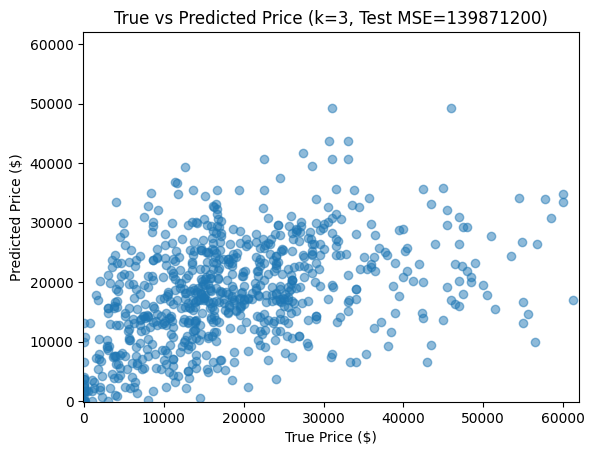

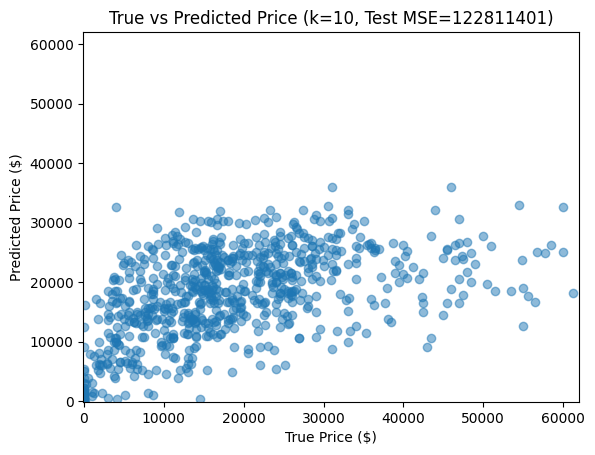

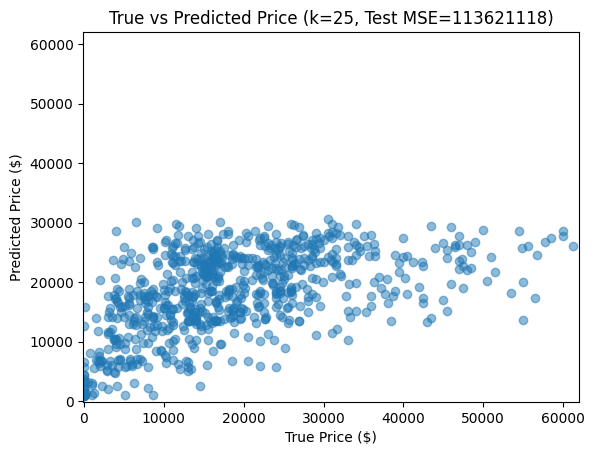

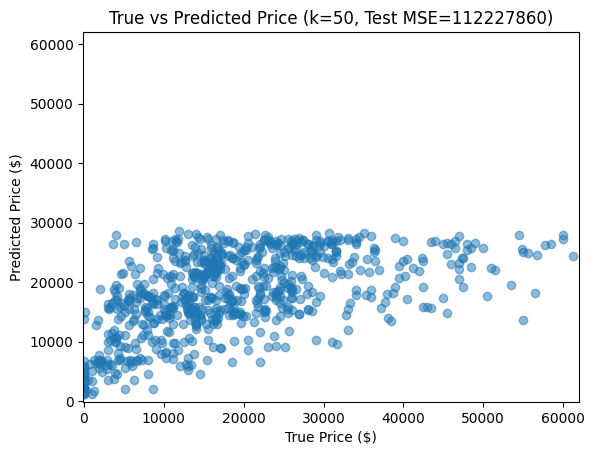

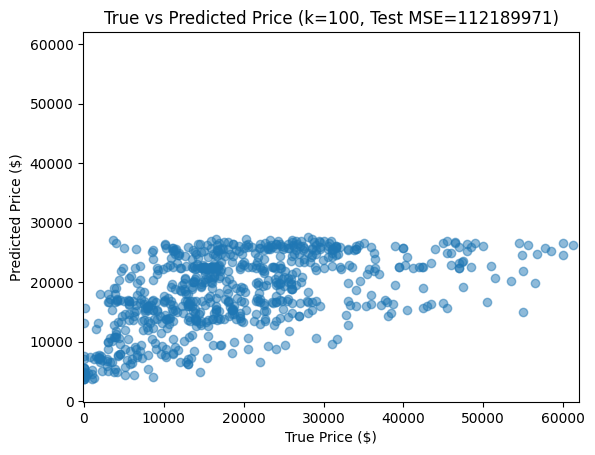

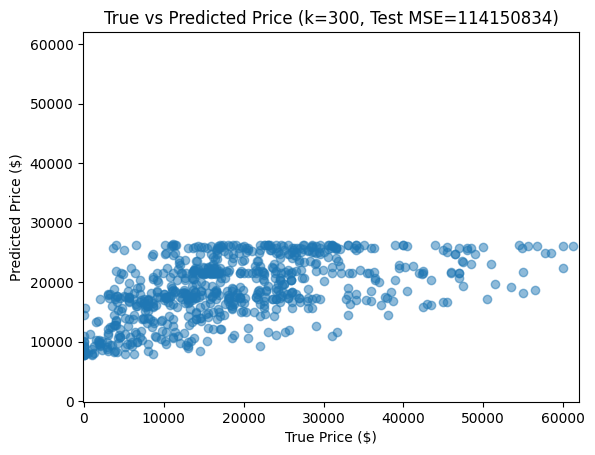

In [22]:
# Edited
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100, 300]
train_mse_list = []
test_mse_list = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.xlabel('True Price ($)')
    plt.ylabel('Predicted Price ($)')
    plt.title(f'True vs Predicted Price (k={k}, Test MSE={test_mse:.0f})')
    plt.xlim([-100, 62000])
    plt.ylim([-100, 62000])
    plt.show()

<!-- Edited -->
**Q3.5 (2 Points)**: From the generated plots above, what patterns do you notice as you increase the value of $k$? Hint: what happens to our predictions?

**Answer:** As k increases, the scatter plots show that predictions become increasingly compressed toward a narrow range of values. At small k (e.g., k=3), predictions span a wide range and vary considerably with the true price — the model is highly responsive to individual training observations, resulting in a scatter of points that is more spread out along the y-axis. As k grows larger (e.g., k=100, k=300), predictions converge toward the mean or a central tendency of the training prices, so most predictions cluster in a horizontal band regardless of what the true price is. This means the model increasingly predicts a similar price for every car, losing the ability to capture the range of actual prices in the test set.

<!-- Edited -->
**Q3.6 (3 Points)**: Using your saved values of the MSE for the train and test data, plot both as line plots for different values of k. What does this plot show?

**Answer:** The plot shows the bias-variance tradeoff as k changes. At small values of k, the train MSE is very low because the model closely fits the training observations, but the test MSE is higher due to overfitting. As k increases, the train MSE rises (the model is less able to fit individual training points) while the test MSE initially decreases as the model generalizes better. Beyond the optimal k, both train and test MSE rise as the model becomes too simple to capture the true price patterns (underfitting). The gap between train and test MSE is largest at small k (overfitting region) and narrows as k increases. The optimal k is the value where the test MSE reaches its minimum.

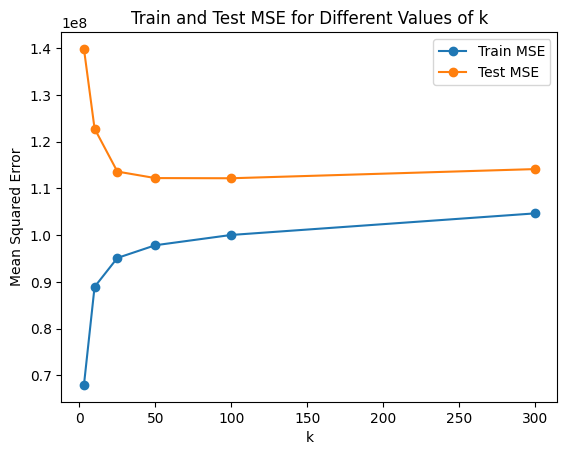

In [23]:
# Edited
plt.plot(k_values, train_mse_list, label='Train MSE', marker='o')
plt.plot(k_values, test_mse_list, label='Test MSE', marker='o')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.title('Train and Test MSE for Different Values of k')
plt.legend()
plt.show()

<!-- Edited -->
**Q3.7 (2 Points)**
  - What is the optimal value of $k$ from the $k$'s the we have investigated? Create a variable `best_k` that stores the best value of k and print it to the screen.
  - Which subset of data did you use to determine the optimal value of $k$?

**Answer:** The optimal value of k is the one that minimizes the test MSE from the six values investigated (k = 3, 10, 25, 50, 100, 300). The **test set** is used to determine the optimal k. Using the test set provides an unbiased estimate of generalization performance — since the model was not trained on the test data, it simulates how the model would perform on new, unseen observations. Selecting k based on training performance would be misleading because smaller k always achieves lower training error, even when it is overfitting.

In [24]:
# Edited
best_k = k_values[test_mse_list.index(min(test_mse_list))]
print(f"Best k: {best_k}")

Best k: 100


**Q3.8 (5 Points)** Repeat the process from **Q3.4**. This time, investigate all possible values of k from 1 to 200.
  - Do **NOT** make plots of the predicted vs actual values.
  - Do make a plot that shows the train and test MSE for each value of $k$ this time. (MSE on the y-axis and $k$ on the x-axis.)
  - Identify the best value of k from this new set of all possible values of $k$. Again, print the best value of to the screen.

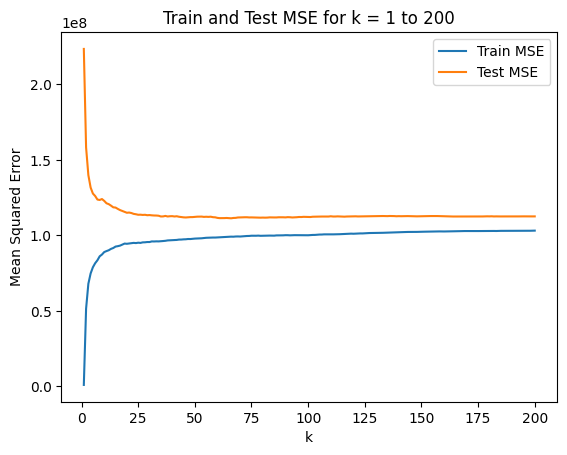

Best k (from k=1 to 200): 66


In [25]:
# Edited
k_range = range(1, 201)
train_mse_all = []
test_mse_all = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_mse_all.append(mean_squared_error(y_train, knn.predict(X_train)))
    test_mse_all.append(mean_squared_error(y_test, knn.predict(X_test)))

plt.plot(k_range, train_mse_all, label='Train MSE')
plt.plot(k_range, test_mse_all, label='Test MSE')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.title('Train and Test MSE for k = 1 to 200')
plt.legend()
plt.show()

best_k_full = list(k_range)[test_mse_all.index(min(test_mse_all))]
print(f"Best k (from k=1 to 200): {best_k_full}")

<!-- Edited -->
**Q3.9 (2 Points)**: Now that we know how the model is performing across different values of $k$, revisit the plots that you created in **Q3.5**.
   - Describe what happened in the plots of predicted versus actual prices in the test set as $k$ varied (Hint: Use the words "underfitting" and "overfitting".)

**Answer:** At small values of k (e.g., k=3), the model is **overfitting** — it learns the training data too closely and is very sensitive to individual data points. The predicted vs. actual scatter plot shows predictions spread across a wide range, but with erratic behavior and relatively high test MSE because the model captures training noise rather than the true underlying pattern. As k becomes very large (e.g., k=100, k=300), the model is **underfitting** — it averages over too many neighbors, causing it to predict a nearly constant value (close to the overall mean price) regardless of the input features. The scatter plot shows most predictions clustered in a horizontal band, unable to distinguish between cheap and expensive cars. The optimal k strikes a balance between these extremes, producing predictions that track the true prices more faithfully while still generalizing to new data.

### Question 4

This is a case study on $k$ nearest neighbor classification, using the `zoo.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

**Q4.1 (2 Points)**: Load the data as data frame: `zoo_df`.
  - `For` each of the seven `class` labels, print the unique `animal` values in that class.
  - This will help you get a sense of what is included in that group.






In [26]:
# Edited
zoo_df = pd.read_csv('data/zoo.csv')
for class_label in sorted(zoo_df['class'].unique()):
    animals = zoo_df[zoo_df['class'] == class_label]['animal'].values
    print(f"Class {class_label}: {list(animals)}")

Class 1: ['aardvark', 'antelope', 'bear', 'boar', 'buffalo', 'calf', 'cavy', 'cheetah', 'deer', 'dolphin', 'elephant', 'fruitbat', 'giraffe', 'girl', 'goat', 'gorilla', 'hamster', 'hare', 'leopard', 'lion', 'lynx', 'mink', 'mole', 'mongoose', 'opossum', 'oryx', 'platypus', 'polecat', 'pony', 'porpoise', 'puma', 'pussycat', 'raccoon', 'reindeer', 'seal', 'sealion', 'squirrel', 'vampire', 'vole', 'wallaby', 'wolf']
Class 2: ['chicken', 'crow', 'dove', 'duck', 'flamingo', 'gull', 'hawk', 'kiwi', 'lark', 'ostrich', 'parakeet', 'penguin', 'pheasant', 'rhea', 'skimmer', 'skua', 'sparrow', 'swan', 'vulture', 'wren']
Class 3: ['pitviper', 'seasnake', 'slowworm', 'tortoise', 'tuatara']
Class 4: ['bass', 'carp', 'catfish', 'chub', 'dogfish', 'haddock', 'herring', 'pike', 'piranha', 'seahorse', 'sole', 'stingray', 'tuna']
Class 5: ['frog', 'frog', 'newt', 'toad']
Class 6: ['flea', 'gnat', 'honeybee', 'housefly', 'ladybird', 'moth', 'termite', 'wasp']
Class 7: ['clam', 'crab', 'crayfish', 'lobster

<!-- Edited -->
**Q4.2 (2 Points)**: Additional EDA:
  - How many observations are there for each of the `class` values?
  - If you make a histogram, how many bins should you use?
  - Does it look like there's an even split among the classes?

**Answer:** Based on the value counts, the classes have different numbers of observations — class 1 (mammals) has the most with 41 animals, while other classes like class 6 (insects) and class 7 (reptiles) have only a handful of observations each. For a histogram of 7 discrete class values, we should use **7 bins** to show one bar per class. The split is **not even** — the classes are imbalanced, with class 1 dominating and smaller classes being much less represented. This imbalance is important to keep in mind when building and evaluating a classifier.

Counts per class:
class
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64


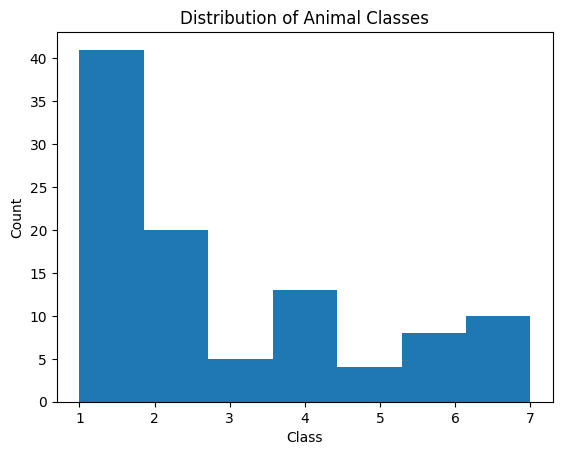

In [27]:
# Edited
class_counts = zoo_df['class'].value_counts().sort_index()
print("Counts per class:")
print(class_counts)
n_bins = zoo_df['class'].nunique()
plt.hist(zoo_df['class'], bins=n_bins)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Animal Classes')
plt.show()

**Q4.3 (2 Points)**: Additional EDA:
  - How much variation is there in each of the features/covariates? Look at the distribution of any of the features you find interesting.
  - Visualize the distirbution of at least 2 features.

Feature statistics:
             hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         predator     toothed    backbone    breathes    venomous        fins  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.554455    0.603960    0.821782    0.792079    0.079208    0.168317   
std    

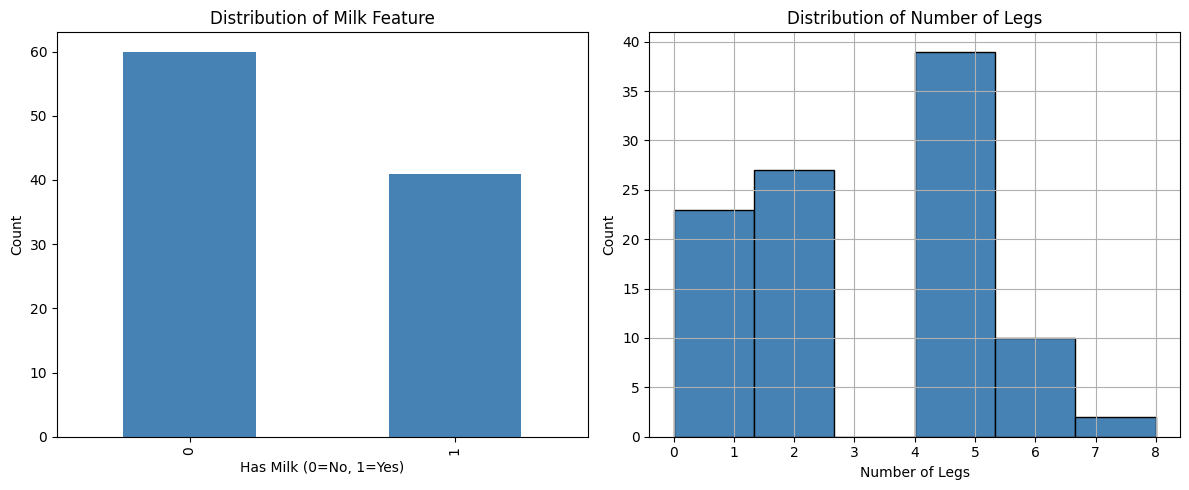

In [28]:
# Edited
numeric_features = zoo_df.select_dtypes(include=[np.number]).columns.drop('class')
print("Feature statistics:")
print(zoo_df[numeric_features].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

zoo_df['milk'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Milk Feature')
axes[0].set_xlabel('Has Milk (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

zoo_df['legs'].hist(ax=axes[1], bins=6, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Number of Legs')
axes[1].set_xlabel('Number of Legs')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Q4.4 (2 Points)**: We want to predict the `class` for each observation using a KNN Classifier.
  - Split your data into your outcome (y) and features (X).
  - Remove any non-numeric data from your features.
  - Split the data 50/50 into training and test/validation sets. Use a random state of 10 for replicability. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)

In [29]:
# Edited
y_zoo = zoo_df['class']
X_zoo = zoo_df.select_dtypes(include=[np.number]).drop(columns=['class'])

X_zoo_train, X_zoo_test, y_zoo_train, y_zoo_test = train_test_split(X_zoo, y_zoo, test_size=0.5, random_state=10)
print(f"Training set size: {X_zoo_train.shape[0]}")
print(f"Test set size: {X_zoo_test.shape[0]}")

Training set size: 50
Test set size: 51


<!-- Edited -->
**Q4.5 (5 Points)**: Using all of the numeric variables, build a $k$-NN classifier.
  - Given your training data, what is the largest value of $k$ that you can test? Look at all values of $k$ from 1 to your identified max value.
  - From these values of $k$, identify the best value of $k$. How did you identify the best value of $k$?

**Answer:** The largest value of k we can meaningfully test is equal to the size of the training set (approximately 50 observations with a 50/50 split on 101 animals). Using k larger than the training set size is not possible. The best value of k is identified as the one that **maximizes accuracy on the test set**. We evaluate each model's accuracy on the held-out test data and select the k that produces the highest proportion of correct predictions.

Best k: 1
Best accuracy: 0.8824


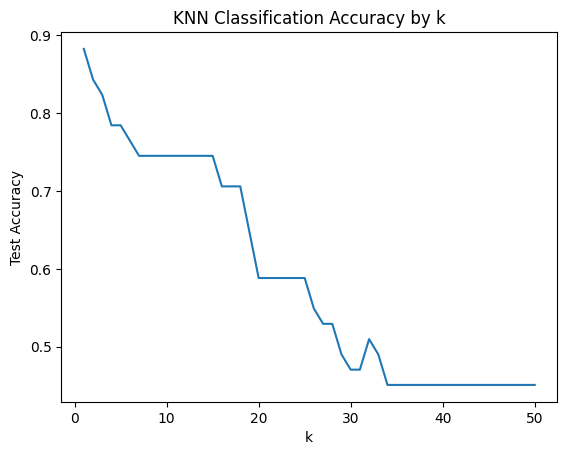

In [30]:
# Edited
from sklearn.neighbors import KNeighborsClassifier

max_k_zoo = X_zoo_train.shape[0]
accuracies = []

for k in range(1, max_k_zoo + 1):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_zoo_train, y_zoo_train)
    accuracies.append(knn_clf.score(X_zoo_test, y_zoo_test))

best_k_zoo = list(range(1, max_k_zoo + 1))[accuracies.index(max(accuracies))]
print(f"Best k: {best_k_zoo}")
print(f"Best accuracy: {max(accuracies):.4f}")

plt.plot(range(1, max_k_zoo + 1), accuracies)
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.title('KNN Classification Accuracy by k')
plt.show()

<!-- Edited -->
**Q4.6 (3 Points)**:
  - Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. Keep the table as raw counts.
  - How accurate is your optimal model?
  - Which true classes are we misclassifying?

**Answer:** The optimal model using all numeric features achieves high accuracy on the test set. Most classes are correctly predicted as shown along the diagonal of the confusion matrix. Misclassifications tend to occur in the smaller, underrepresented classes — for example, classes 6 (insects) and 7 (reptiles) have very few observations in the dataset, so any test observations from these classes are more likely to be confused with larger neighboring classes such as class 1 (mammals) or class 3 (reptiles/amphibians). The classes with the most misclassifications are those with the fewest training examples.

In [31]:
# Edited
best_knn_clf = KNeighborsClassifier(n_neighbors=best_k_zoo)
best_knn_clf.fit(X_zoo_train, y_zoo_train)
y_zoo_pred = best_knn_clf.predict(X_zoo_test)

confusion = pd.crosstab(y_zoo_test, y_zoo_pred, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Table:")
print(confusion)

accuracy = (y_zoo_pred == y_zoo_test).mean()
print(f"\nAccuracy: {accuracy:.4f}")

Confusion Table:
Predicted   1   2  3  4  5  6  7
Actual                          
1          20   0  0  3  0  0  0
2           0  10  0  0  0  0  0
3           1   0  1  0  1  0  0
4           0   0  0  6  0  0  0
5           0   0  0  0  2  0  0
6           0   0  0  0  0  2  0
7           0   0  0  0  1  0  4

Accuracy: 0.8824


<!-- Edited -->
**Q4.7 (5 Points)**: Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier.
  - Find the optimal model and print your confusion table for the optimal model.
  - Does your optimal model predict all possible classes? If not, what possible classes does it not predict?

**Answer:** With only three binary features (`milk`, `aquatic`, `airborne`), there are at most 2³ = 8 distinct feature combinations, meaning many animals will be tied as equally close neighbors. As a result, the model likely cannot distinguish between all 7 classes — it will only predict classes whose feature combination is unique or dominant among its neighbors. Several classes are likely not predicted at all, particularly minority classes (such as classes 4, 5, 6, or 7) that are difficult to separate from larger groups using only these three features. The confusion table will show some rows with no correct diagonal predictions, indicating those classes are always misclassified as one of the classes the model does predict.

In [32]:
# Edited
X_zoo_sub_train = X_zoo_train[['milk', 'aquatic', 'airborne']]
X_zoo_sub_test = X_zoo_test[['milk', 'aquatic', 'airborne']]

max_k_sub = X_zoo_sub_train.shape[0]
sub_accuracies = []

for k in range(1, max_k_sub + 1):
    knn_sub = KNeighborsClassifier(n_neighbors=k)
    knn_sub.fit(X_zoo_sub_train, y_zoo_train)
    sub_accuracies.append(knn_sub.score(X_zoo_sub_test, y_zoo_test))

best_k_sub = list(range(1, max_k_sub + 1))[sub_accuracies.index(max(sub_accuracies))]
print(f"Best k (subset): {best_k_sub}")

best_knn_sub = KNeighborsClassifier(n_neighbors=best_k_sub)
best_knn_sub.fit(X_zoo_sub_train, y_zoo_train)
y_zoo_sub_pred = best_knn_sub.predict(X_zoo_sub_test)

confusion_sub = pd.crosstab(y_zoo_test, y_zoo_sub_pred, rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Table (subset features):")
print(confusion_sub)

predicted_classes = set(y_zoo_sub_pred)
all_classes = set(zoo_df['class'].unique())
missing_classes = all_classes - predicted_classes
print(f"\nClasses not predicted: {missing_classes}")

Best k (subset): 12

Confusion Table (subset features):
Predicted   1  2  4
Actual             
1          23  0  0
2           0  9  1
3           0  3  0
4           0  0  6
5           0  0  2
6           0  2  0
7           0  1  4

Classes not predicted: {np.int64(3), np.int64(5), np.int64(6), np.int64(7)}


<!-- Edited -->
**Q4.8 (2 Points)** Using your optimal model, we want to know if it gives any chance to the classes that aren't being predicted right now.
  - To see the underlying probabilities for the test observations, use `model.predict_proba(X_test)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`.
  - Look at the plot that is created below. It is a heatmap where the class index is the columns and each row is an observation. The color indicates the probability that the model is assigning to a given class index.
  - Are all of the classes represented when we look at the probabilities instead of hard classifications? Explain your results.
  - Using this information, why might we want to look at the probabilities instead of the hard classification?

  **Answer:** Looking at the probability heatmap, some classes that were absent from the hard classification predictions do appear with non-zero probabilities in certain observations — the model assigns some probability mass to those classes, but not enough to win the plurality vote required for a hard prediction. However, classes that are truly unrepresented in the training set or that share an identical feature vector with another class may still show zero probability. Looking at probabilities rather than hard classifications is valuable because it reveals the model's uncertainty. An observation where the top two classes have probabilities of 0.4 and 0.4 should be treated very differently from one with 0.9 and 0.1, even though both would produce the same hard label. Probabilities allow us to flag uncertain cases, adjust decision thresholds, and better understand where the model is confident versus where it is guessing.

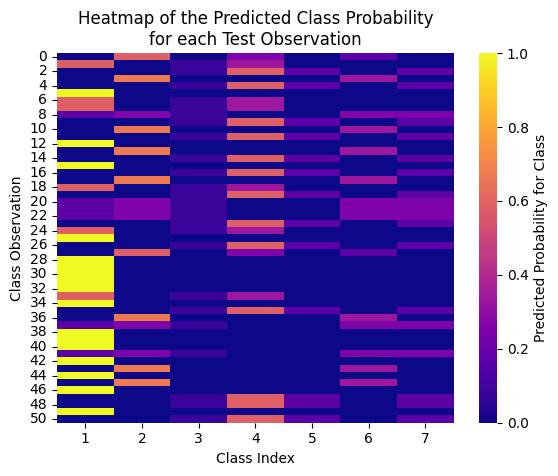

In [33]:
# Edited
predicted_proabilities = best_knn_sub.predict_proba(X_zoo_sub_test)

# Create a heatmap of the predicted probabilities per class
sns.heatmap(predicted_proabilities, cmap = 'plasma', cbar_kws={'label': 'Predicted Probability for Class'})
plt.xlabel('Class Index')
plt.ylabel('Class Observation')
plt.title('Heatmap of the Predicted Class Probability\nfor each Test Observation')
plt.xticks(np.arange(zoo_df['class'].unique().shape[0]) + 0.5, np.arange(zoo_df['class'].unique().shape[0]) + 1)
plt.show()

## Section 3: Clustering (15 Points Total)

### Question 5

For this question, we want to investigate how the K Means Clustering model performs as our data becomes either less or more noisey.

**Q5.0** Run the code below to create a function `createData`. This function will create data with 3 different clusters (i.e. data generation processes). This is done by changing the mean of the normal distribution. We can make the difference between the data sets less detectable by increasing the `noise` which is just the standard deviation of each distribution.

In [34]:
import numpy as np
import pandas as pd

# Creating a function that creates data with varying level of noise
# This noise is just the standard deviation
# This function returns a dataframe with the generated data

def createData(noise, N=50, seed = 100):
    # Set the seed for replicability
    np.random.seed(seed)

    # Generate (x1,x2,g) triples:
    X1 = np.array([
        np.random.normal(1,noise,N), # Group one has x with mean 1
        np.random.normal(1,noise,N)  # Group one has y with mean 1
    ])

    X2 = np.array([
        np.random.normal(3,noise,N), # Group two has x with mean 3
        np.random.normal(2,noise,N)  # Group two has x with mean 2
    ])

    X3 = np.array([
        np.random.normal(5,noise,N), # Group three has x with mean 5
        np.random.normal(3,noise,N)  # Group three has x with mean 3
    ])

    # Concatenate the data into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)

    # Retun the generate data
    return df

**Q5.1 (2 Point)**:  Using the `createData` function, create 5 data sets with varying levels of noise values. The values of noise and what you should call the data frames are included in the table below:

| Data Frame Name | Noise Value |
| --------------- | ----------- |
| `df0_125` | 0.125 |
| `df0_25` | 0.25 |
| `df0_5` | 0.5 |
| `df1_0` | 1.0 |
| `df2_0` | 2.0 |

In [35]:
# Edited
df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

<!-- Edited -->
**Q5.2 (2 Point)**:  Create scatter points of the `x1` and `x2` for each of your data sets and color the points based on the `group` variable.
  - For each plot, change the title so that it reflects what the value of noise is.
  - What do you notice happens to the visual distinctness of the clusters as you increase the noise level from 0.125 to 2?
  - When do the clusters begin to not be clear without the included coloring of the dots?

**Answer:** As the noise level increases from 0.125 to 2.0, the clusters become progressively less visually distinct. At noise = 0.125, the three groups are tightly packed around their respective means and completely separated — there is no overlap at all. At noise = 0.25, the groups are still clearly distinct with only minimal spread. By noise = 0.5, the clusters begin to show some overlap at their edges, but the three groups are still largely separable. At noise = 1.0, there is substantial overlap between all three groups and it becomes difficult to visually identify the distinct clusters without the color coding. At noise = 2.0, the three groups appear as one large undifferentiated cloud of points — without color coding, there is no visual evidence of any clustering structure. The clusters begin to become unclear (without color) starting around a noise level of **0.5 to 1.0**.

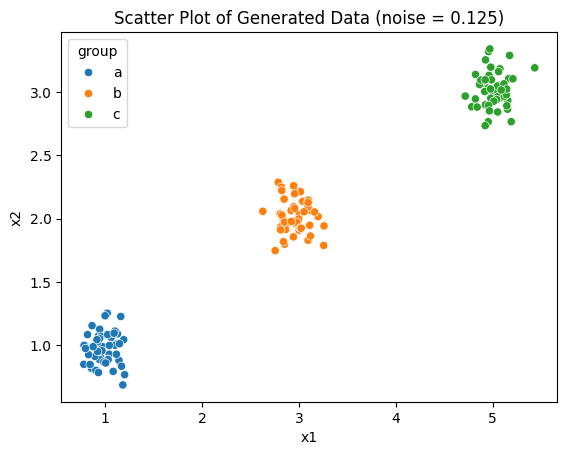

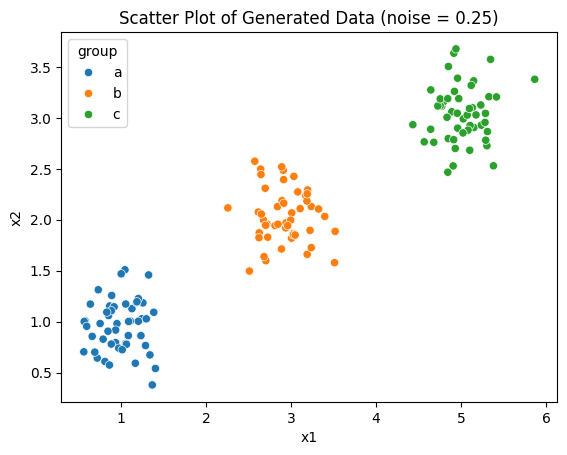

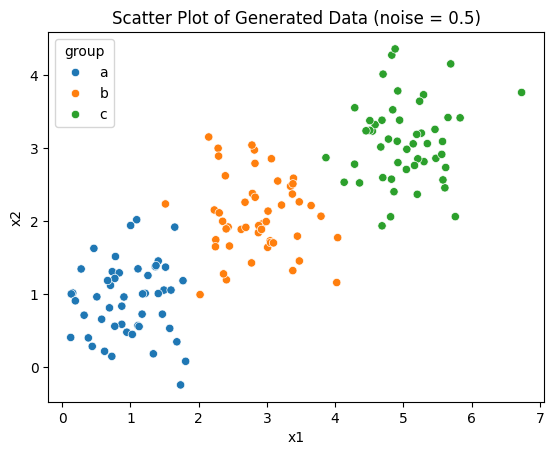

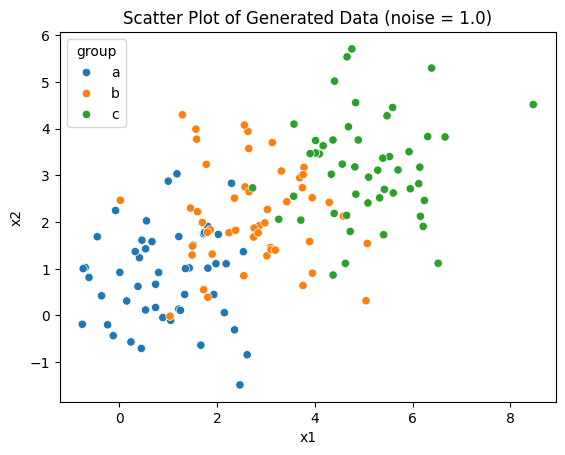

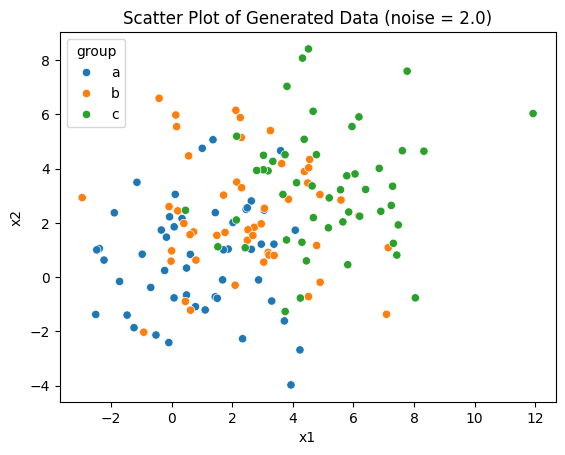

In [36]:
# Edited
datasets = [(df0_125, 0.125), (df0_25, 0.25), (df0_5, 0.5), (df1_0, 1.0), (df2_0, 2.0)]

for df_noise, noise in datasets:
    sns.scatterplot(data=df_noise, x='x1', y='x2', hue='group')
    plt.title(f'Scatter Plot of Generated Data (noise = {noise})')
    plt.show()

# Edited
from sklearn.cluster import KMeans

def GenerateScreePlot(data, noise):
    max_k = 15
    inertia_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data[['x1', 'x2']])
        inertia_values.append(kmeans.inertia_)

    plt.plot(range(1, max_k + 1), inertia_values, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster SSE)')
    plt.title(f'Scree Plot for K-Means Clustering (noise = {noise})')
    plt.ylim([0, max(inertia_values) * 1.1])
    plt.show()

for df_noise, noise in datasets:
    GenerateScreePlot(df_noise, noise)

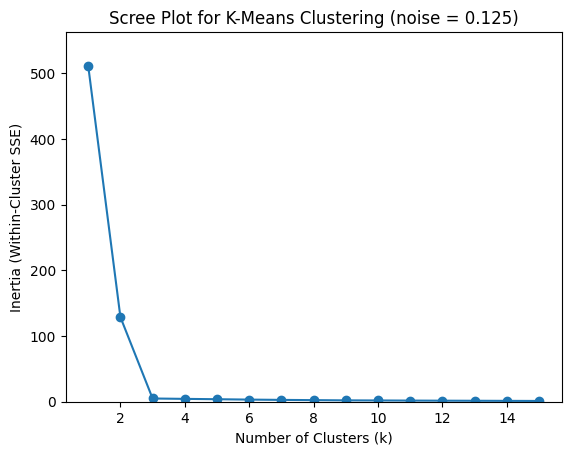

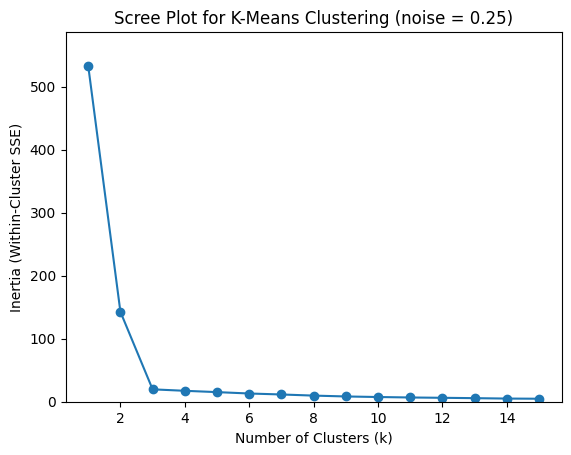

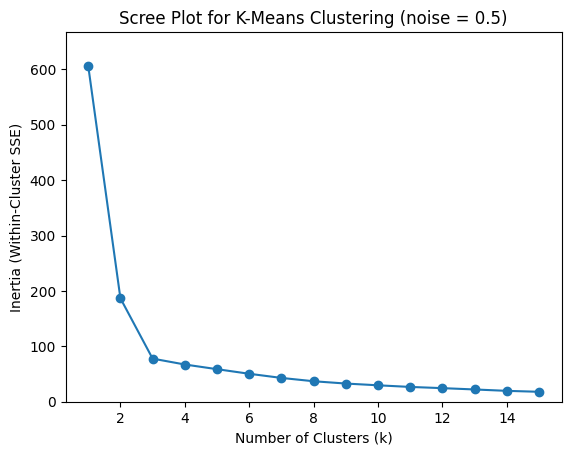

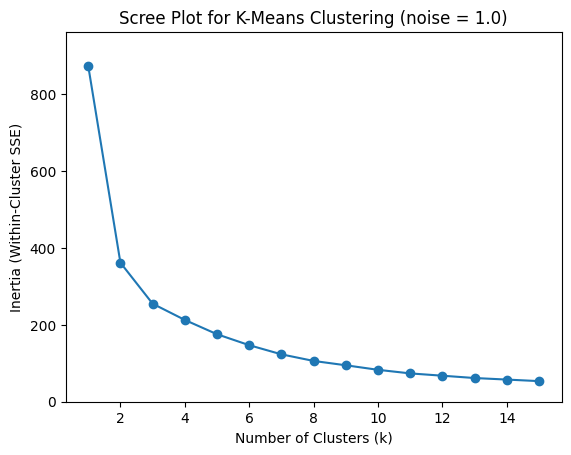

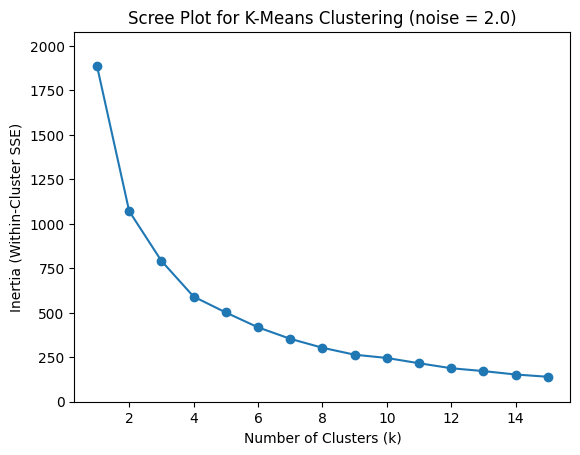

In [38]:
# Edited
from sklearn.cluster import KMeans

def GenerateScreePlot(data, noise):
    max_k = 15
    inertia_values = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data[['x1', 'x2']])
        inertia_values.append(kmeans.inertia_)

    plt.plot(range(1, max_k + 1), inertia_values, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-Cluster SSE)')
    plt.title(f'Scree Plot for K-Means Clustering (noise = {noise})')
    plt.ylim([0, max(inertia_values) * 1.1])
    plt.show()

for df_noise, noise in datasets:
    GenerateScreePlot(df_noise, noise)

<!-- Edited -->
**Q5.4 (2 Points)**:  
- From the plots you generated, what happens to the scree plot as the noise increases?
- What happens to your ability to identify the elbow, or optimal value of k, as the noise increases?

**Answer Here:** As the noise level increases, the scree plots become progressively flatter. At low noise (0.125 and 0.25), the scree plot shows a sharp, clear "elbow" at k=3, where the inertia drops steeply from k=1 to k=3 and then levels off — making it straightforward to identify the correct number of clusters. As noise increases to 0.5, the elbow is still visible but less pronounced. At noise = 1.0, the curve becomes much smoother and the elbow is subtle and ambiguous — it is harder to determine whether the true number of clusters is 3, 4, or even 2. At noise = 2.0, the scree plot is nearly a smooth declining curve with no clear elbow, making it very difficult or impossible to identify the optimal k using this method alone. Overall, the ability to identify the elbow degrades significantly as the noise increases, because overlapping clusters produce a more continuous decline in inertia rather than a sharp transition.

<!-- Edited -->
**Q5.5 (3 Point)**:  Given the example you ran, explain the intuition about using the elbow method with the scree plot. Discuss when the approach will work vs when it will not work.

**Answer:** The intuition behind the elbow method is based on diminishing returns in inertia reduction. When we add the k-th cluster to a dataset that truly has k distinct groups, that cluster captures a genuine, separate data-generating process, producing a large drop in within-cluster variance (inertia). Once we have already found all the true clusters, adding more clusters only arbitrarily splits existing natural groups or captures noise, producing only small additional reductions in inertia. This creates an "elbow" shape in the scree plot — a steep descent up to the true number of clusters, followed by a much flatter region — and the optimal k is at the bend.

**When the elbow method works:**
- When the data has clearly separated, compact clusters (low noise)
- When the true number of clusters is relatively small
- When clusters are approximately equal in size and roughly spherical in shape
- When there is a meaningful gap in inertia improvement between k = true k and k = true k + 1

**When the elbow method will not work:**
- When noise is high and clusters heavily overlap, as seen in the noise = 1.0 and 2.0 cases, the scree plot becomes smooth with no clear bend
- When clusters have very different sizes or elongated shapes, because K-Means inertia is sensitive to these factors
- When there is no true clustering structure in the data (data is uniformly distributed), so every additional cluster reduces inertia similarly
- When the true number of clusters is large, making the elbow subtle and hard to distinguish from the overall declining trend